In [23]:
#command to run the notebook with all the variables and libraries needed for this notebook

%run /home/anomalocaris/LB2_project_group_9/SVM/SVM_benchmark.ipynb


[1/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset1_arricchito.tsv
[2/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset2_arricchito.tsv
[3/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset3_arricchito.tsv
[4/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset4_arricchito.tsv
[5/6] Loading /home/anomalocaris/LB2_project_group_9/SVM/subset5_arricchito.tsv
[6/6] Loading /home/anomalocaris/LB2_project_group_9/Data Preparation/benchmark_arricchito.tsv

Loaded 6 datasets
File 1: 1605 sequences
File 2: 1605 sequences
File 3: 1604 sequences
File 4: 1603 sequences
File 5: 1603 sequences
File 6: 2006 sequences

Split sizes:
  Train: 6415
  Val:   1605
  Test:  2006

Using 698 positive training sequences to train the PSWM

Detected 33 total features (indices 0..32).
Using 26 selected features.

Best SVM params on selected features: {'C': 10.0, 'gamma': 0.01}, Val MCC = 0.774

FINAL TEST MCC (benchmark, selected features) = 0.752


In [24]:
bench_seq_control=[] #lista che controlla ogni sequenza del benchmark se risulta TP,TF,FP,FN 

for i in range(len(y_test)):
    if y_test[i]==0 and y_pred_test[i]==0:
        bench_seq_control.append("TN")
    elif y_test[i]==1 and y_pred_test[i]==1:
        bench_seq_control.append("TP")
    elif y_test[i]==1 and y_pred_test[i]==0:
        bench_seq_control.append("FN")
    else: #if y_test[i]==0 and y_pred_test[i]==1:
        bench_seq_control.append("FP")

In [25]:
df=pd.read_csv("/home/anomalocaris/LB2_project_group_9/Data Preparation/benchmark_arricchito_with_target.tsv",sep="\t")

series_results_bench=pd.Series(bench_seq_control)

df["results"]=series_results_bench

In [26]:
df3=df.query('results=="FP" or results=="FN"')

df3.groupby("Kingdom").count()


,Accession,Organism,Sequence length,SP cleavage,transmembrane_term,Sequence,positive/negative,results
Kingdom,,,,,,,,
Discoba,1,1,1,1,1,1,1,1
Fungi,9,9,9,9,9,9,9,9
Metazoa,74,74,74,74,74,74,74,74
Sar,1,1,1,1,1,1,1,1
Viridiplantae,9,9,9,9,9,9,9,9


defaultdict(<class 'int'>, {'Metazoa': 74, 'Viridiplantae': 9, 'Fungi': 9, 'Sar': 1, 'Discoba': 1})


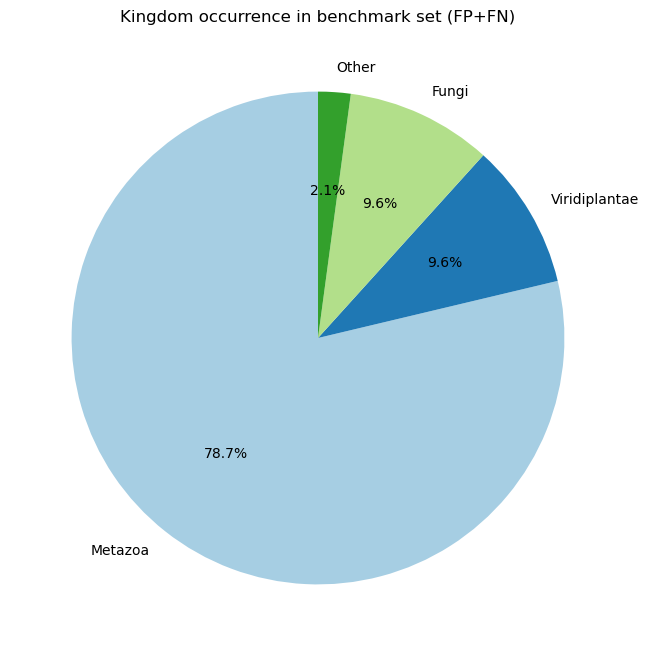

In [27]:
df_benchmark_kingdom=df3["Kingdom"].tolist()
total_entries_benchmark=len(df_benchmark_kingdom)
kingdoms_benchmark=defaultdict(int) #inizializza dizionario vuoto con valori uguali a zero, che poi sarà aggiornato durante il for loop

for element in df_benchmark_kingdom:
        kingdoms_benchmark[element]+=1
print(kingdoms_benchmark)
benchmark_pie = pd.DataFrame(kingdoms_benchmark.items(), columns=["Kingdom", "Occurrence"])

# Grouping the lesser represented taxa as "Other"
benchmark_pie = benchmark_pie.sort_values(by='Occurrence', ascending=False)
threshold = 5 # You can adjust this value

small_values = benchmark_pie[benchmark_pie['Occurrence'] < threshold]
main_values = benchmark_pie[benchmark_pie['Occurrence'] >= threshold]

# Create a new row for "Other"
other_occurrence = small_values['Occurrence'].sum()
other_row = pd.DataFrame([{'Kingdom': 'Other', 'Occurrence': other_occurrence}])

# Combine the data
cleaned_pie_data = pd.concat([main_values, other_row])

# Create the new pie chart
plt.figure(figsize=(8, 8))
plt.pie(cleaned_pie_data['Occurrence'], labels=cleaned_pie_data['Kingdom'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Add title
plt.title('Kingdom occurrence in benchmark set (FP+FN)')
plt.savefig("Kingdom_occurrence_in_benchmark_set_pie.png",dpi=300, bbox_inches="tight")
plt.show()

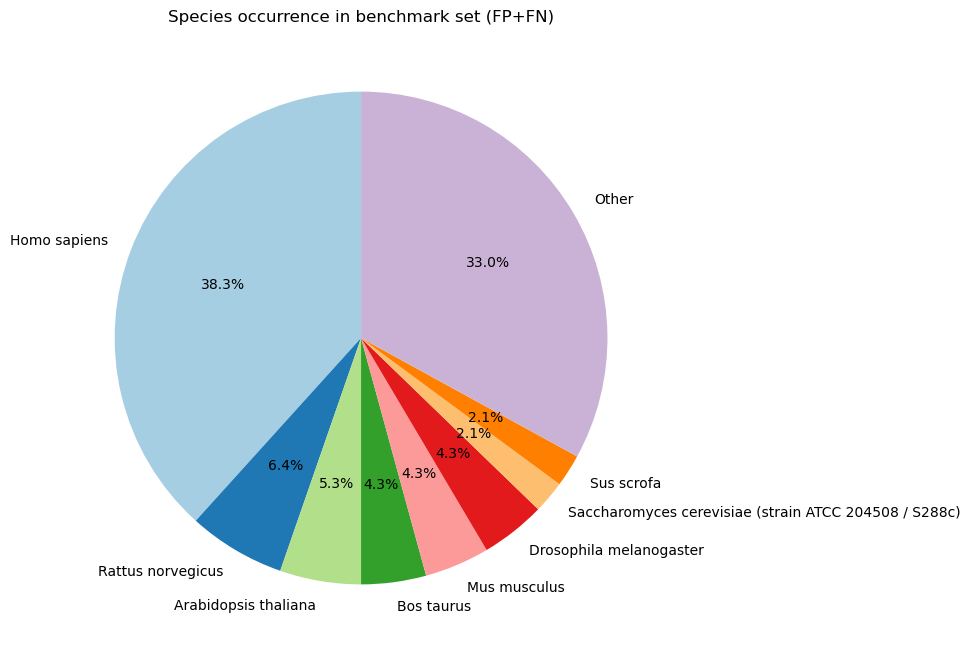

In [28]:
df_benchmark_organism=df3["Organism"].tolist()
total_entries_benchmark=len(df_benchmark_organism)
organism_benchmark=defaultdict(int) #inizializza dizionario vuoto con valori uguali a zero, che poi sarà aggiornato durante il for loop

for element in df_benchmark_organism:
        organism_benchmark[element]+=1

species_benchmark_pie = pd.DataFrame(organism_benchmark.items(), columns=["Organism", "Occurrence"])

# Grouping the lesser represented taxa as "Other"
species_benchmark_pie = species_benchmark_pie.sort_values(by='Occurrence', ascending=False)
threshold =  2 # You can adjust this value

small_values = species_benchmark_pie[species_benchmark_pie['Occurrence'] < threshold]
main_values = species_benchmark_pie[species_benchmark_pie['Occurrence'] >= threshold]

# Create a new row for "Other"
other_occurrence = small_values['Occurrence'].sum()
other_row = pd.DataFrame([{'Organism': 'Other', 'Occurrence': other_occurrence}])

# Combine the data
cleaned_pie_data = pd.concat([main_values, other_row])

# Create the new pie chart
plt.figure(figsize=(8, 8))
plt.pie(cleaned_pie_data['Occurrence'], labels=cleaned_pie_data['Organism'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Add title
plt.title('Species occurrence in benchmark set (FP+FN)')
plt.savefig("Species_occurrence_in_benchmark_set_pie.png",dpi=300, bbox_inches="tight")
plt.show()


In [29]:
df3_fp=df3.query('results=="FP"')

In [30]:
df['transmembrane_term'].value_counts()

transmembrane_term
False    1654
Null      219
True      133
Name: count, dtype: int64

In [31]:
df3_fp['transmembrane_term'].value_counts()

transmembrane_term
True     20
False    19
Name: count, dtype: int64

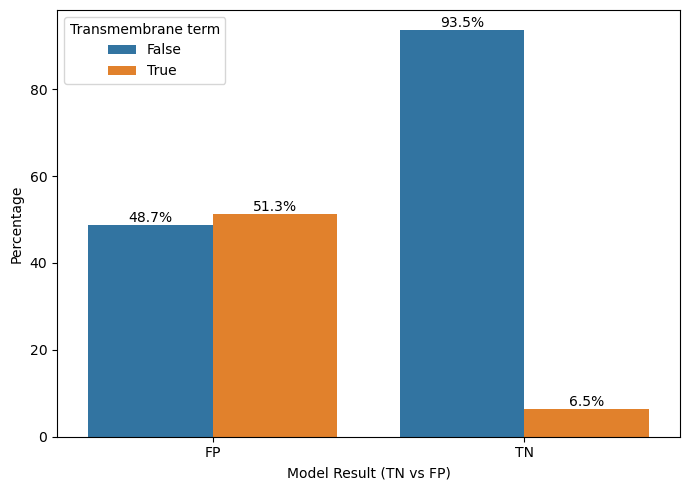

In [32]:
# Keep only the rows where the model result is TN or FP
df_sub = df[df["results"].isin(["TN", "FP"])]

# Exclude Null values in transmembrane_term ONLY for plotting
df_sub = df_sub[df_sub["transmembrane_term"].notna()]

# Count how many entries exist for each combination of (result, transmembrane_term)
counts = (
    df_sub
    .groupby(["results", "transmembrane_term"])
    .size()
    .rename("n")
    .reset_index()
)

# Compute percentages within each "results" group (TN or FP)
counts["percent"] = counts.groupby("results")["n"].transform(
    lambda s: (s / s.sum()) * 100
)

# Create the barplot
plt.figure(figsize=(7,5))
ax = sns.barplot(
    data=counts,
    x="results",              # TN and FP on the x-axis
    y="percent",              # percentage values
    hue="transmembrane_term"  # True vs False (no Null)
)

# Axis labels
ax.set_ylabel("Percentage")
ax.set_xlabel("Model Result (TN vs FP)")

# Legend title
ax.legend(title="Transmembrane term")

# Add percentage labels above each bar
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")


plt.tight_layout()
plt.savefig(f"TN_vs_FP_results.png", dpi=300)
plt.show()

In [33]:
# lists for each group
logo_pos_seqs = []   # all true positives (class = Positive)
logo_neg_seqs = []   # all true negatives (class = Negative)
logo_fn_seqs  = []   # only FN
logo_fp_seqs  = []   # only FP

# --- NEGATIVE CLASS (true label = Negative) ---

# all negatives: positive/negative == 0
logo_neg = df[df["positive/negative"] == 0]

# take N-terminal window [1:18] for all negatives
for _, row in logo_neg.iterrows():
    seq = row["Sequence"]
    subseq = seq[1:18]                  # same as your original code
    logo_neg_seqs.append(subseq)

    # subset: false positives (true negative but predicted positive)
    if row["results"] == "FP":
        logo_fp_seqs.append(subseq)

# --- POSITIVE CLASS (true label = Positive) ---

# all positives: positive/negative == 1
logo_pos = df[df["positive/negative"] == 1]

for _, row in logo_pos.iterrows():
    seq = row["Sequence"]
    cleavage_position = int(row["SP cleavage"])      # position of SP cleavage
    subseq = seq[cleavage_position-13:cleavage_position+2]
    logo_pos_seqs.append(subseq)

    # subset: false negatives (true positive but predicted negative)
    if row["results"] == "FN":
        logo_fn_seqs.append(subseq)

# all four sequence sets collected here
logo_fullseqs = [logo_pos_seqs, logo_fn_seqs, logo_neg_seqs, logo_fp_seqs]


/home/anomalocaris/anaconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'X' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 1000x300 with 0 Axes>

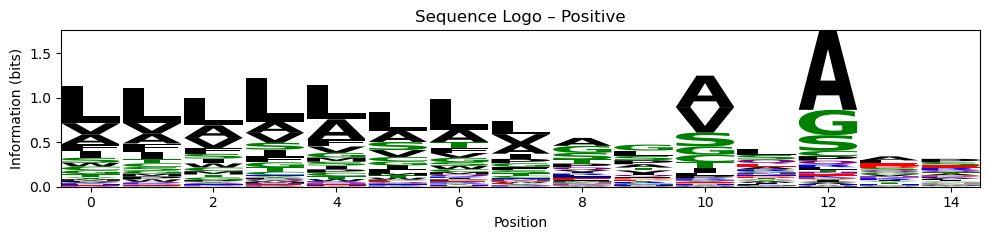

/home/anomalocaris/anaconda3/lib/python3.12/site-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'X' is not in color_dict. Using black.
  warnings.warn(str(Error))


<Figure size 1000x300 with 0 Axes>

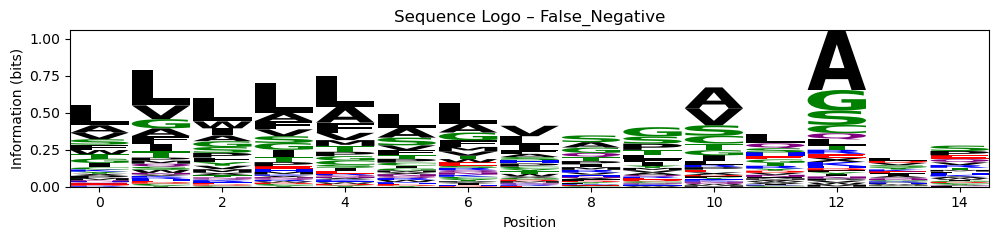

<Figure size 1000x300 with 0 Axes>

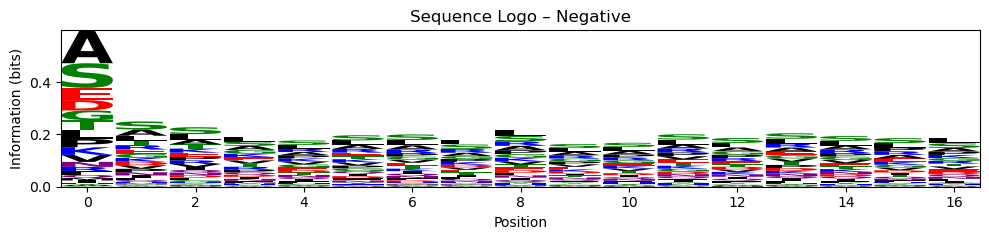

<Figure size 1000x300 with 0 Axes>

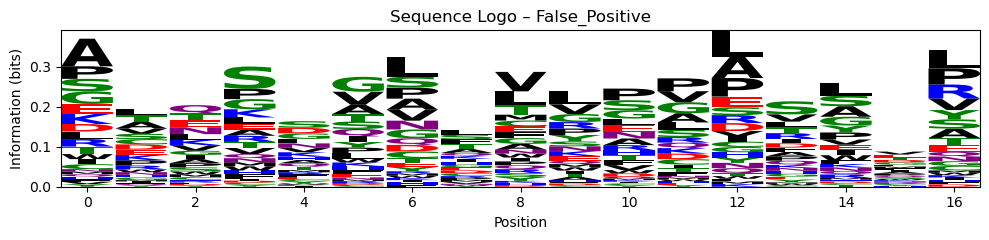

In [34]:
# Dictionary of all sets
logo_sets = {
    "Positive":       logo_pos_seqs,
    "False_Negative": logo_fn_seqs,
    "Negative":       logo_neg_seqs,
    "False_Positive": logo_fp_seqs,
}

for name, seqs in logo_sets.items():

    # Skip groups with no sequences
    if len(seqs) == 0:
        print(f"Skipping {name}: no sequences available.")
        continue

    # Convert alignment → information matrix
    mat = lm.alignment_to_matrix(sequences=seqs, to_type='information')

    # Create one figure per logo
    plt.figure(figsize=(10, 3))
    lm.Logo(mat, color_scheme="chemistry")
    plt.title(f"Sequence Logo – {name}")
    plt.xlabel("Position")
    plt.ylabel("Information (bits)")
    plt.tight_layout()
    plt.savefig(f"{name}_logo.png", dpi=300)
    plt.show()


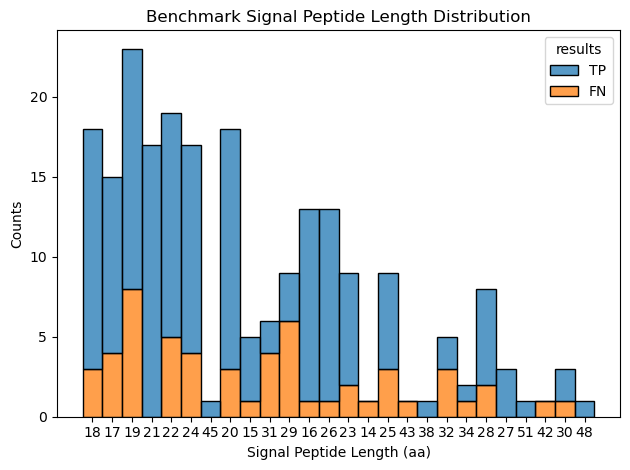

In [127]:
# Keep only TRUE positives (positive = 1)
length_df = df[df["positive/negative"] == 1].copy()

# Compute signal peptide length using SP cleavage column
# (because SP starts at position 1)
length_df["sp_length"] = length_df["SP cleavage"]

# Plot histogram grouped by prediction results (TP, FP, FN, TN)
sns.histplot(
    data=length_df,
    x="sp_length",
    hue="results",
    multiple="stack",   # stacked histogram
    bins=20             # adjust if needed
)

plt.title("Benchmark Signal Peptide Length Distribution")
plt.ylabel("Counts")
plt.xlabel("Signal Peptide Length (aa)")

plt.tight_layout()
plt.savefig("SignalPeptide_length_distribution.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
"""
Capire se i falsi negativi (FN) derivano dal fatto che la loro regione N-terminale (i primi K residui) ha una composizione amminoacidica diversa rispetto a:

-    gli esempi positivi del training set

-i veri positivi (TP) riconosciuti correttamente dal modello

.Se la composizione del N-term dei FN è diversa, significa che lo SVM può aver appreso una caratteristica sbagliata o troppo limitata di quella regione.
"""

files_training_SVM=["/home/anomalocaris/LB2_project_group_9/SVM/subset2_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset3_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset4_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset5_arricchito.tsv"]
pos_train_seq=[]

for file in files_training_SVM:
    train_set=pd.read_csv(file,sep="\t")
    train_set['positive/negative'] = np.where(train_set['SP cleavage'] == 'False', 0, 1).astype(int)
    calamaro = train_set[train_set['positive/negative']==1]
    
    pos_seq=[]

    for _, row in calamaro.iterrows():
        sequence = row["Sequence"]
        cleavage = int(row["SP cleavage"])
        # estraggo la porzione di interesse
        pos_seq.append(sequence[cleavage-13:cleavage+2])
        
    pos_train_seq+=pos_seq

In [65]:
df_benchmark_tp=df.query('results=="TP"')
df_benchmark_fn=df.query('results=="FN"')

list_benchmark_tp=[]
list_benchmark_fn=[]

for _, row in df_benchmark_tp.iterrows():
        sequence = row["Sequence"]
        cleavage = int(row["SP cleavage"])
        # estraggo la porzione di interesse
        list_benchmark_tp.append(sequence[cleavage-13:cleavage+2])
for _, row in df_benchmark_fn.iterrows():
        sequence = row["Sequence"]
        cleavage = int(row["SP cleavage"])
        # estraggo la porzione di interesse
        list_benchmark_fn.append(sequence[cleavage-13:cleavage+2])

In [69]:
len(list_benchmark_tp)


164

In [67]:
len(list_benchmark_fn)

55

In [116]:
from collections import Counter

AMINOACIDS = ['A','C','D','E','F','G','H','I','K','L',
              'M','N','P','Q','R','S','T','V','W','Y']

def residue_freq(lista, AMINOACIDS):
    # concateno tutte le sequenze in una super-sequenza
    full_seq = "".join(lista)

    # conto tutte le occorrenze globali
    counts = Counter(full_seq)

    # totale dei residui
    L = len(full_seq)

    # frequenza per ogni aa
    freq = {f"{aa}": round((counts.get(aa, 0) / L),4)*100 for aa in AMINOACIDS}

    return freq


In [117]:
diz_res_tp=residue_freq(list_benchmark_tp,AMINOACIDS)
diz_res_fn=residue_freq(list_benchmark_fn,AMINOACIDS)
diz_res_train=residue_freq(pos_train_seq,AMINOACIDS)

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

benchmark_tp_plot = pd.DataFrame(diz_res_tp.items(), columns=["Residue", "Frequency (%)"])
benchmark_tp_plot['Dataset'] = 'benchmark_true_positive'
benchmark_fn_plot = pd.DataFrame(diz_res_fn.items(), columns=["Residue", "Frequency (%)"])
benchmark_fn_plot['Dataset'] = 'benchmark_false_negative'
training_pos = pd.DataFrame(diz_res_train.items(), columns=["Residue", "Frequency (%)"])
training_pos['Dataset'] = 'training_positive'




In [124]:
dataframe_comparison=pd.concat([benchmark_tp_plot,benchmark_fn_plot,training_pos], ignore_index=True)

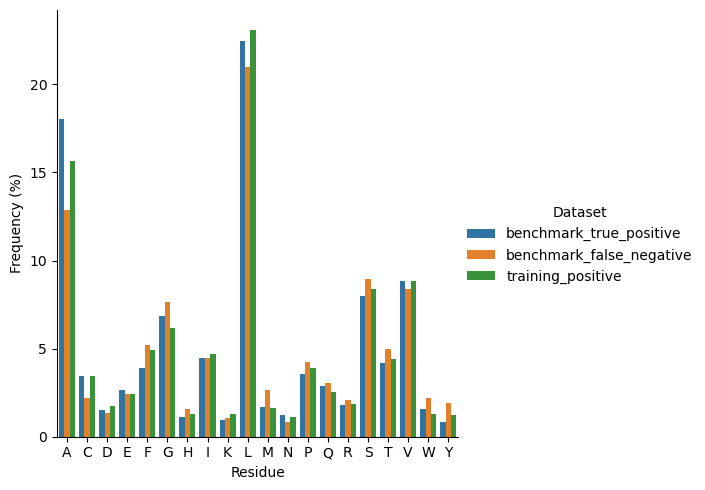

In [ ]:
"""comparison delle composizioni """
sns.catplot(
    data=dataframe_comparison,
    x="Residue",
    y="Frequency (%)",
    hue="Dataset",  
    kind="bar"      
)

plt.savefig("residue_frequency_total_comparison.png", dpi=300, bbox_inches="tight")

In [129]:
files_training_SVM=["/home/anomalocaris/LB2_project_group_9/SVM/subset2_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset3_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset4_arricchito.tsv","/home/anomalocaris/LB2_project_group_9/SVM/subset5_arricchito.tsv"]

all_train_pos=pd.DataFrame()
for file in files_training_SVM:
    train_set=pd.read_csv(file,sep="\t")
    train_set['positive/negative'] = np.where(train_set['SP cleavage'] == 'False', 0, 1).astype(int)
    calamaro = train_set[train_set['positive/negative']==1]
    all_train_pos=pd.concat([all_train_pos,calamaro],ignore_index=True)

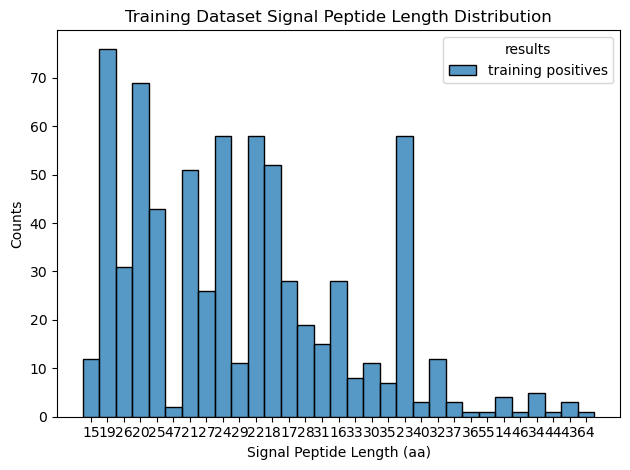

In [137]:
all_train_pos["results"]="training positives"
# Keep only TRUE positives (positive = 1)

length_df = all_train_pos[all_train_pos["positive/negative"] == 1].copy()


# Compute signal peptide length using SP cleavage column
# (because SP starts at position 1)
length_df["sp_length"] = length_df["SP cleavage"]

# Plot histogram grouped by prediction results (TP, FP, FN, TN)
sns.histplot(
    data=length_df,
    x="sp_length",
    hue="results",
    multiple="stack",   # stacked histogram
    bins=20             # adjust if needed
)

plt.title("Training Dataset Signal Peptide Length Distribution")
plt.ylabel("Counts")
plt.xlabel("Signal Peptide Length (aa)")

plt.tight_layout()
plt.savefig("Training_Pos_SignalPeptide_length_distribution.png", dpi=300)
plt.show()

In [135]:
signal_peptide_length_comparison=pd.concat([df,all_train_pos],ignore_index=True)

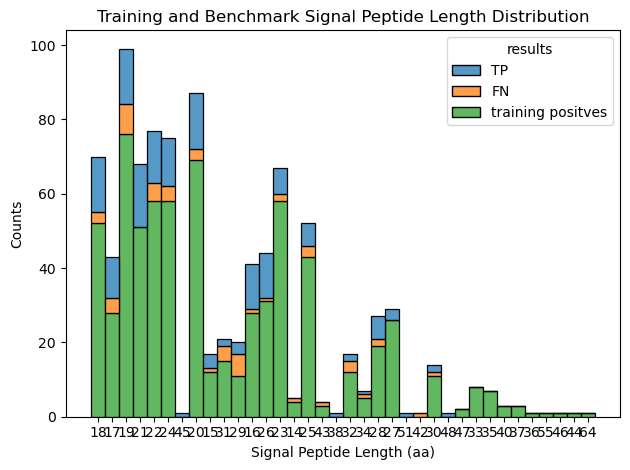

In [138]:
length_df = signal_peptide_length_comparison[signal_peptide_length_comparison["positive/negative"] == 1].copy()

# Compute signal peptide length using SP cleavage column
# (because SP starts at position 1)
length_df["sp_length"] = length_df["SP cleavage"]

# Plot histogram grouped by prediction results (TP, FP, FN, TN)
sns.histplot(
    data=length_df,
    x="sp_length",
    hue="results",
    multiple="stack",   # stacked histogram
    bins=20             # adjust if needed
)

plt.title("Training and Benchmark Signal Peptide Length Distribution")
plt.ylabel("Counts")
plt.xlabel("Signal Peptide Length (aa)")

plt.tight_layout()
plt.savefig("SignalPeptide_length_distribution_comparison_bench_train.png", dpi=300)
plt.show()